In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
import itertools
import seaborn as sns
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


In [2]:
plt.rcParams['font.family'] = 'Arial'

In [3]:
features=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\traits_allgroups.xlsx')

In [4]:
features

,replicate,number_of_tube,media,strain,clade,ecotype,depth,location,max_FL,max_day,growth_rate,peak_count,D_value,norm_toPRO99
0,1,A1,PRO99,MED4,HLI,HL,5,Mediterranean,6.705,12.912500,0.377,3,20.147917,103.403074
1,2,A2,PRO99,MED4,HLI,HL,5,Mediterranean,6.457,14.018056,0.394,4,15.986111,99.578471
2,3,A3,PRO99,MED4,HLI,HL,5,Mediterranean,6.291,12.330556,0.391,4,16.456944,97.018455
3,1,A4,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.866,18.927778,0.395,1,9.859722,75.042410
4,2,A5,lowN (1:8),MED4,HLI,HL,5,Mediterranean,4.609,16.813194,0.393,1,9.290972,71.079011
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247,2,D56,lowP (1:8),NATL1A,LLI,LL,30,North_Atlantic,8.143,6.988194,0.433,2,9.915972,98.432589
248,3,D57,lowP (1:8),NATL1A,LLI,LL,30,North_Atlantic,7.740,6.988194,0.454,2,10.984722,93.561125
249,1,D58,lowP (1:50),NATL1A,LLI,LL,30,North_Atlantic,1.250,6.988194,0.223,3,12.330556,15.110001
250,2,D59,lowP (1:50),NATL1A,LLI,LL,30,North_Atlantic,1.128,6.988194,0.209,1,12.330556,13.635265


In [5]:
# averageing controls and replicates
features_averagedc=features.pivot_table(values=['max_FL', 'max_day', 'growth_rate', 'peak_count', 
                                                  'D_value', 'norm_toPRO99']
                                     ,index=['media', 'strain', 'clade', 'location', 'depth'], 
                                                    sort=False)

In [6]:
features_averagedc = features_averagedc.reset_index(drop=False)
features_averagedc.head()

,media,strain,clade,location,depth,max_FL,max_day,growth_rate,peak_count,D_value,norm_toPRO99
0,PRO99,MED4,HLI,Mediterranean,5,6.239167,10.459954,0.407500,4.166667,20.683681,100.000000
1,lowN (1:8),MED4,HLI,Mediterranean,5,5.081000,13.187847,0.399083,1.250000,9.954051,81.458223
2,lowP (1:8),MED4,HLI,Mediterranean,5,6.302750,11.225752,0.390000,4.000000,26.659259,101.161487
3,lowP (1:50),MED4,HLI,Mediterranean,5,1.949667,10.927662,0.373917,2.916667,24.792535,31.268770
4,PRO99,MIT9312,HLII,Gulf_Stream,135,5.878083,9.645139,0.436917,3.333333,21.636343,100.000000


In [7]:
nutr_gene=pd.read_excel(r'C:\Users\yaras\OneDrive\Desktop\Analysis for paper\Python Code\nutrient_genes.xlsx')

In [8]:
nutr_gene

,strain,temp_woa,nitrate_woa,phosphate_woa,pgenes,ngenes,GC_content
0,MED4,13.34,2.36,0.11,34,22,30.80
1,NATL2A,17.34,3.17,0.11,28,25,35.10
2,MIT9515,26.81,2.84,0.40,14,11,30.80
3,MIT9202,26.77,0.78,0.05,17,18,31.10
4,NATL1A,16.89,0.87,0.13,28,25,35.00
5,MIT9312,19.54,1.47,0.36,27,22,31.20
6,MIT9313,19.54,1.47,0.36,22,25,50.70
7,MIT1327,20.34,0.93,0.18,17,23,50.26
8,MIT0604,20.04,2.85,0.18,20,39,31.20
9,MIT9215,25.61,5.73,0.76,16,19,31.10


In [9]:
nutr_gene.columns

Index(['strain', 'temp_woa', 'nitrate_woa', 'phosphate_woa', 'pgenes',
       'ngenes', 'GC_content'],
      dtype='object')

In [20]:
n_sen_d = nutr_gene[nutr_gene['strain'].isin(['MED4', 'MIT9515', 'MIT9202', 'MIT9215', 'MIT0604', 'AS9601', 'MIT9312', 'MIT1314', 'NATL1A'])]
n_sen_d['sensitivity_d'] = 'N_sensitivity'

other_sen_d = nutr_gene[nutr_gene['strain'].isin(['MIT9313', 'MIT1327', 'MIT9301', 'SB', 'NATL2A', 'PAC1'])]
other_sen_d['sensitivity_d'] = 'Mixed'


combined_d = pd.concat([n_sen_d, other_sen_d])

combined_d


C:\Users\yaras\AppData\Local\Temp\ipykernel_3044\1938717876.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n_sen_d['sensitivity_d'] = 'N_sensitivity'
C:\Users\yaras\AppData\Local\Temp\ipykernel_3044\1938717876.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  other_sen_d['sensitivity_d'] = 'Mixed'


,strain,temp_woa,nitrate_woa,phosphate_woa,pgenes,ngenes,GC_content,sensitivity_d
0,MED4,13.34,2.36,0.11,34,22,30.80,N_sensitivity
2,MIT9515,26.81,2.84,0.40,14,11,30.80,N_sensitivity
3,MIT9202,26.77,0.78,0.05,17,18,31.10,N_sensitivity
4,NATL1A,16.89,0.87,0.13,28,25,35.00,N_sensitivity
5,MIT9312,19.54,1.47,0.36,27,22,31.20,N_sensitivity
8,MIT0604,20.04,2.85,0.18,20,39,31.20,N_sensitivity
9,MIT9215,25.61,5.73,0.76,16,19,31.10,N_sensitivity
10,AS9601,26.52,2.90,0.63,16,19,31.30,N_sensitivity
13,MIT1314,20.34,0.93,0.13,20,18,31.16,N_sensitivity
1,NATL2A,17.34,3.17,0.11,28,25,35.10,Mixed


In [21]:
combined_d
combined_d = combined_d.rename(columns={
    'temp_woa': 'Temperature (°C)',
    'nitrate_woa': 'Nitrate (μmol/kg)',
    'phosphate_woa': 'Phosphate (μmol/kg)',
    'pgenes': 'Number of P-acquisition genes',
    'ngenes': 'Number of N-acquisition genes',
    'GC_content': 'GC content (%)'
})

combined_d

,strain,Temperature (°C),Nitrate (μmol/kg),Phosphate (μmol/kg),Number of P-acquisition genes,Number of N-acquisition genes,GC content (%),sensitivity_d
0,MED4,13.34,2.36,0.11,34,22,30.80,N_sensitivity
2,MIT9515,26.81,2.84,0.40,14,11,30.80,N_sensitivity
3,MIT9202,26.77,0.78,0.05,17,18,31.10,N_sensitivity
4,NATL1A,16.89,0.87,0.13,28,25,35.00,N_sensitivity
5,MIT9312,19.54,1.47,0.36,27,22,31.20,N_sensitivity
8,MIT0604,20.04,2.85,0.18,20,39,31.20,N_sensitivity
9,MIT9215,25.61,5.73,0.76,16,19,31.10,N_sensitivity
10,AS9601,26.52,2.90,0.63,16,19,31.30,N_sensitivity
13,MIT1314,20.34,0.93,0.13,20,18,31.16,N_sensitivity
1,NATL2A,17.34,3.17,0.11,28,25,35.10,Mixed


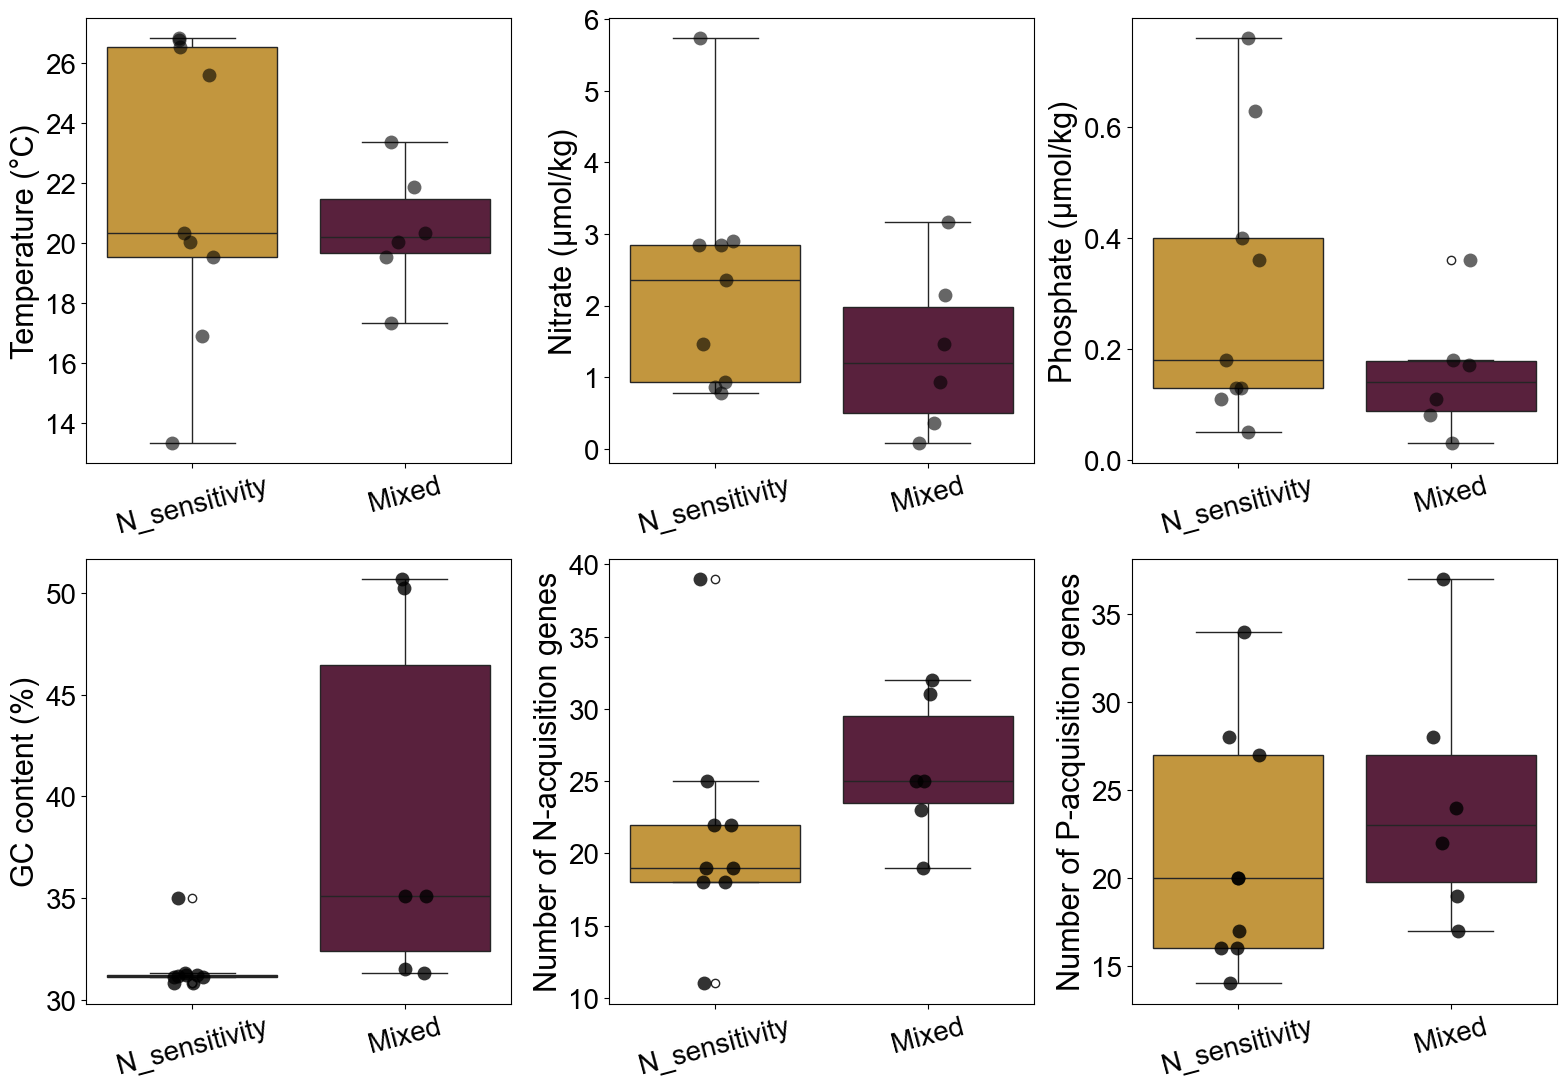

In [26]:
row1_lst = ['Temperature (°C)', 'Nitrate (μmol/kg)', 'Phosphate (μmol/kg)']
row2_lst = ['GC content (%)', 'Number of N-acquisition genes', 'Number of P-acquisition genes']

palette = {'N_sensitivity': '#D89E28', 'Mixed': '#62183D'}
fig, axes = plt.subplots(2, 3, figsize=(16, 11)) 


for i, col in enumerate(row1_lst):
    ax = axes[0, i]
    sns.boxplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, hue='sensitivity_d',
                palette=palette, legend=False)
    sns.stripplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, 
                  color='black', alpha=0.6, jitter=True, dodge=True, size=10)
    
    ax.set_xlabel('', fontsize=20)
    ax.set_ylabel(col, fontsize=22)
    ax.tick_params(axis='x', labelsize=20, rotation=15)
    ax.tick_params(axis='y', labelsize=20)


for i, col in enumerate(row2_lst):
    ax = axes[1, i]
    sns.boxplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, hue='sensitivity_d',
                palette=palette, legend=False)
    sns.stripplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, 
                  color='black', alpha=0.8, jitter=True, dodge=True, size=10)
    
    ax.set_xlabel('')
    ax.set_ylabel(col, fontsize=22)
    ax.tick_params(axis='x', labelsize=20, rotation=15)
    ax.tick_params(axis='y', labelsize=20)


plt.tight_layout()
plt.show()

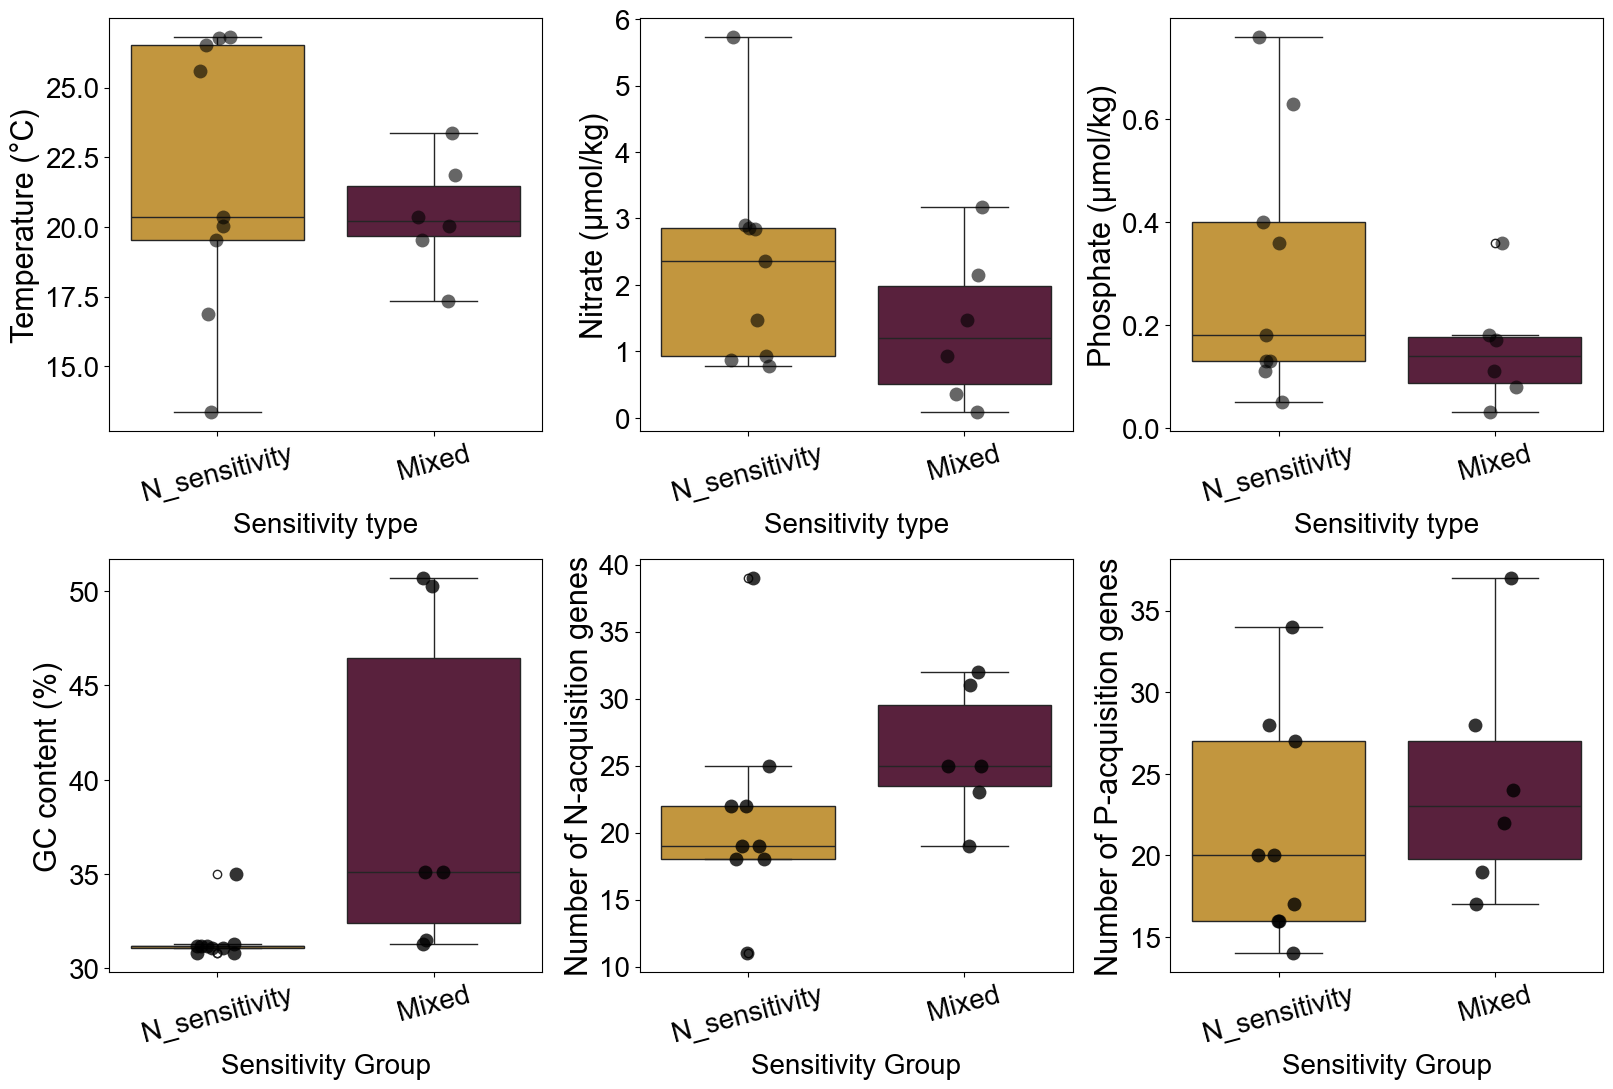

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

row1_lst = ['Temperature (°C)', 'Nitrate (μmol/kg)', 'Phosphate (μmol/kg)']
row2_lst = ['GC content (%)', 'Number of N-acquisition genes', 'Number of P-acquisition genes']

palette = {'N_sensitivity': '#D89E28', 'Mixed': '#62183D'}
fig, axes = plt.subplots(2, 3, figsize=(16, 11)) 

for i, col in enumerate(row1_lst):
    ax = axes[0, i]
    sns.boxplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, hue='sensitivity_d',
                palette=palette, legend=False)
    sns.stripplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, 
                  color='black', alpha=0.6, jitter=True, dodge=True, size=10)
    
    ax.set_xlabel('Sensitivity type', fontsize=20)
    ax.set_ylabel(col, fontsize=22)
    ax.tick_params(axis='x', labelsize=20, rotation=15)
    ax.tick_params(axis='y', labelsize=20)

for i, col in enumerate(row2_lst):
    ax = axes[1, i]
    sns.boxplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, hue='sensitivity_d',
                palette=palette, legend=False)
    sns.stripplot(data=combined_d, x='sensitivity_d', y=col, ax=ax, 
                  color='black', alpha=0.8, jitter=True, dodge=True, size=10)
    
    ax.set_xlabel('Sensitivity Group', fontsize=20)
    ax.set_ylabel(col, fontsize=22)
    ax.tick_params(axis='x', labelsize=20, rotation=15)
    ax.tick_params(axis='y', labelsize=20)

# Increase distance between panels (tweak these numbers to taste)
plt.subplots_adjust(wspace=0.4, hspace=0.7)

plt.tight_layout()
plt.show()

In [13]:
df_transposed = nutr_gene.T 
df_transposed.columns = df_transposed.iloc[0]  # Set the first row as headers
df_transposed = df_transposed[1:] 
df_transposed

strain,MED4,NATL2A,MIT9515,MIT9202,NATL1A,MIT9312,MIT9313,MIT1327,MIT0604,MIT9215,AS9601,SB,MIT9301,MIT1314,PAC1
temp_woa,13.34,17.34,26.81,26.77,16.89,19.54,19.54,20.34,20.04,25.61,26.52,23.37,20.05,20.34,21.85
nitrate_woa,2.36,3.17,2.84,0.78,0.87,1.47,1.47,0.93,2.85,5.73,2.9,2.15,0.36,0.93,0.08
phosphate_woa,0.11,0.11,0.4,0.05,0.13,0.36,0.36,0.18,0.18,0.76,0.63,0.17,0.03,0.13,0.08
pgenes,34,28,14,17,28,27,22,17,20,16,16,24,37,20,19
ngenes,22,25,11,18,25,22,25,23,39,19,19,32,19,18,31
GC_content,30.8,35.1,30.8,31.1,35.0,31.2,50.7,50.26,31.2,31.1,31.3,31.5,31.3,31.16,35.1


In [14]:
def mann_whitney_test(df):
    # Define the strain groups
    n_sen_d = ['MED4', 'MIT9312', 'MIT0604', 'MIT9515', 'MIT9215', 'AS9601', 'MIT9202', 'NATL1A', 'MIT1314']
    other_sen_d = ['SB', 'PAC1', 'NATL2A', 'MIT1327', 'MIT9313', 'MIT9301']
    measurments = df.index

    # Create an empty list to store results
    results = []

    for measurment in measurments:
        # Convert data to numeric and handle any non-numeric values
        data1 = pd.to_numeric(df.loc[measurment, n_sen_d], errors='coerce')
        data2 = pd.to_numeric(df.loc[measurment, other_sen_d], errors='coerce')



        # Perform the Mann-Whitney U test
        stat, p_value = mannwhitneyu(data1, data2)

        # Determine the direction of the effect
        median_n = data1.median()
        median_other = data2.median()
        if median_n > median_other:
            direction = 'N'
        else:
            direction = 'Other'

        # Store the results
        results.append([measurment, stat, p_value, median_n, median_other, direction])

    # Convert the results to a DataFrame
    results_df = pd.DataFrame(results, columns=['measurment', 'U_statistic', 'p_value', 'median_N', 'median_Other', 'Direction'])

    # Adjust p-values for multiple testing
    adjusted_p_values = multipletests(results_df['p_value'], method='fdr_bh')[1]
    results_df['adjusted_p_values'] = adjusted_p_values

    return results_df

# Perform the Mann-Whitney U test and get the results dataframe
results_df = mann_whitney_test(df_transposed)
results_df


,measurment,U_statistic,p_value,median_N,median_Other,Direction,adjusted_p_values
0,temp_woa,31.0,0.679447,20.34,20.195,N,0.679447
1,nitrate_woa,36.0,0.315606,2.36,1.200,N,0.378727
2,phosphate_woa,37.5,0.236911,0.18,0.140,N,0.378727
3,pgenes,18.0,0.314737,20.00,23.000,Other,0.378727
4,ngenes,12.0,0.084653,19.00,25.000,Other,0.253958
5,GC_content,2.5,0.004495,31.16,35.100,Other,0.026972


In [15]:
def mann_whitney_test(df):
    # Define the strain groups
    HL = ['MED4', 'MIT9312', 'MIT0604', 'MIT9515', 'MIT9215', 'AS9601', 'MIT9202',  'MIT1314', 'SB','MIT9301']
    LL = [ 'PAC1', 'NATL2A', 'NATL1A', 'MIT9313', 'MIT1327']
    measurments = df.index

    # Create an empty list to store results
    results = []

    for measurment in measurments:
        # Convert data to numeric and handle any non-numeric values
        data1 = pd.to_numeric(df.loc[measurment, HL], errors='coerce')
        data2 = pd.to_numeric(df.loc[measurment, LL], errors='coerce')



        # Perform the Mann-Whitney U test
        stat, p_value = mannwhitneyu(data1, data2)

        # Determine the direction of the effect
        median_HL = data1.median()
        median_LL = data2.median()
        if median_HL > median_LL:
            direction = 'HL'
        else:
            direction = 'LL'

        # Store the results
        results.append([measurment, stat, p_value, median_HL, median_LL, direction])

    # Convert the results to a DataFrame
    results_df_ecot = pd.DataFrame(results, columns=['measurment', 'U_statistic', 'p_value', 'median_HL', 'median_LL', 'Direction'])

    # Adjust p-values for multiple testing
    adjusted_p_values = multipletests(results_df['p_value'], method='fdr_bh')[1]
    results_df_ecot['adjusted_p_values'] = adjusted_p_values

    return results_df_ecot

# Perform the Mann-Whitney U test and get the results dataframe
results_df_ecot = mann_whitney_test(df_transposed)
results_df_ecot



,measurment,U_statistic,p_value,median_HL,median_LL,Direction,adjusted_p_values
0,temp_woa,37.0,0.158251,21.855,19.54,HL,0.679447
1,nitrate_woa,33.0,0.357467,2.255,0.93,HL,0.378727
2,phosphate_woa,30.0,0.580185,0.175,0.13,HL,0.378727
3,pgenes,20.5,0.622962,20.000,22.00,LL,0.378727
4,ngenes,10.0,0.073141,19.000,25.00,LL,0.253958
5,GC_content,0.0,0.002577,31.180,35.10,LL,0.026972
